<a href="https://www.kaggle.com/code/onphct/lol-win-rate-prediction?scriptVersionId=311478081" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
import requests
import time
import json
import seaborn as sns
import matplotlib.pyplot as plt



In [19]:
# CODE BLOCK FOR GET THE MATCH_ID THROUGH API KEY

API_KEY = "YOUR_RIOT_API_KEY"
HEADERS = {"X-Riot-Token": API_KEY}
# Optional server
URL_KR = "https://kr.api.riotgames.com"  # URL for get the player's id 
URL_ASIA = "https://asia.api.riotgames.com"  # URL for get the match's id

def get_challenger_puuids():
    """Get list of player's id in Challenger rank"""
    print("Taking player's id list....")
    url = f"{URL_KR}/lol/league/v4/challengerleagues/by-queue/RANKED_SOLO_5x5"
    response = requests.get(url, headers=HEADERS)

    if response.status_code == 200:
        entries = response.json()['entries']
        
        puuid_list = [e['puuid'] for e in entries]

        print(f"Success ({len(puuid_list)} player's id)")
        return puuid_list
    else:
        print(f"Error: {response.status_code}")
        return []


def get_match_ids(puuid, num_matches=20):
    """Get list of match's id in Challenger rank"""
    url = f"{URL_ASIA}/lol/match/v5/matches/by-puuid/{puuid}/ids?queue=420&start=0&count={num_matches}"
    response = requests.get(url, headers=HEADERS)

    if response.status_code == 200:
        return response.json()
    return []



# Bước 3: Ghi ra file


In [ ]:
unique_matches = set()
challenger_puuids = get_challenger_puuids()

for i, puuid in enumerate(challenger_puuids, 1):
    match_ids = get_match_ids(puuid, num_matches=20)
    print(f"Taking match's id of player {i}...")
    for mid in match_ids:
        unique_matches.add(mid)
        
    time.sleep(1.2)

print("FINISH")
print(f"Total: {len(unique_matches)} matches")

with open("match_ids_dataset.txt", "w") as file:
    for mid in unique_matches:
        file.write(mid + "\n")

In [7]:
def get_all_champions():
    """Fetch the full list of champions from Data Dragon"""
    version_url = "https://ddragon.leagueoflegends.com/api/versions.json"
    latest_version = requests.get(version_url).json()[0]

    # Load JSON containing all champion data
    champ_url = f"https://ddragon.leagueoflegends.com/cdn/{latest_version}/data/en_US/champion.json"
    response = requests.get(champ_url)

    if response.status_code == 200:
        champ_data = response.json()
        # Extract champion names (keys from the 'data' dictionary)
        all_champ = sorted(list(champ_data['data'].keys()))
        print(f"Successfully retrieved {len(all_champ)} champions.")
        return all_champ
    else:
        print("Could not connect to Data Dragon.")
        return []

def get_match_info(match_id):
    """Fetch general match details"""
    url = f'https://asia.api.riotgames.com/lol/match/v5/matches/{match_id}'
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        return response.json()
        
    elif response.status_code == 429:
        time.sleep(120) 
    else:
        print(f"API Error: {response.status_code} at {match_id}")
        return None 

def get_match_timeline(match_id):
    """Fetch detailed match timeline (event-by-event)"""
    url = f'https://asia.api.riotgames.com/lol/match/v5/matches/{match_id}/timeline'
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        return response.json()
        
    elif response.status_code == 429:
        time.sleep(120) 
    else:
        print(f"API Error: {response.status_code} at {match_id}")
        return None 

def get_early_diff(timeline, minute):
    """Calculate early game statistics at a specific minute"""
    frames = timeline['info']['frames']
    # Fallback if match ends before specified minute
    target_idx = min(minute, len(frames) - 1)
    frame = frames[target_idx]

    blue_gold, red_gold = 0, 0
    blue_level, red_level = 0, 0
    blue_horde, red_horde = 0, 0
    blue_dragons, red_dragons = 0, 0

    # Participant IDs 1-5 = Blue Team, 6-10 = Red Team
    for i in range(1, 11):
        p_frame = frame['participantFrames'][str(i)]
        if i <= 5:
            blue_gold += p_frame['totalGold']
            blue_level += p_frame['level']
        else:
            red_gold += p_frame['totalGold']
            red_level += p_frame['level']

    for f in range(target_idx + 1):
        for event in frames[f].get('events', []):
            if event.get('type') == 'ELITE_MONSTER_KILL':
                m_type = event.get('monsterType')
                killer_id = event.get('killerId')
                # 'HORDE' refers to Voidgrubs in the API
                if m_type == 'HORDE':
                    if 1 <= killer_id <= 5: blue_horde += 1
                    elif 6 <= killer_id <= 10: red_horde += 1
                elif m_type == 'DRAGON':
                    if 1 <= killer_id <= 5: blue_dragons += 1
                    elif 6 <= killer_id <= 10: red_dragons += 1
                        
    return (blue_gold - red_gold), (blue_level - red_level), (blue_horde - red_horde), (blue_dragons - red_dragons)

def get_mid_diff(timeline, minute):
    """Calculate mid game statistics (objectives, gold, level)"""
    frames = timeline['info']['frames']
    target_idx = min(minute, len(frames) - 1)
    frame = frames[target_idx]
    
    blue_gold, red_gold = 0, 0
    blue_level, red_level = 0, 0
    for i in range(1, 11):
        p_frame = frame['participantFrames'][str(i)]
        if i <= 5:
            blue_gold += p_frame['totalGold']
            blue_level += p_frame['level']
        else:
            red_gold += p_frame['totalGold']
            red_level += p_frame['level']

    blue_towers, red_towers = 0, 0
    blue_dragons, red_dragons = 0, 0
    blue_heralds, red_heralds = 0, 0
    blue_barons, red_barons = 0, 0
    
    # Iterate from start to specified mid-game mark (e.g., 30m)
    for f in range(target_idx + 1):
        for event in frames[f].get('events', []):
            # 1. Tower Kills
            if event.get('type') == 'BUILDING_KILL' and event.get('buildingType') == 'TOWER_BUILDING':
                if event.get('teamId') == 100: red_towers += 1 # Blue Tower lost = Red scores
                else: blue_towers += 1
            
            # 2. Epic Monsters (Dragons, Heralds, Barons)
            if event.get('type') == 'ELITE_MONSTER_KILL':
                killer_id = event.get('killerId')
                m_type = event.get('monsterType')
                if m_type == 'DRAGON':
                    if 1 <= killer_id <= 5: blue_dragons += 1
                    elif 6 <= killer_id <= 10: red_dragons += 1
                elif m_type == 'RIFTHERALD':
                    if 1 <= killer_id <= 5: blue_heralds += 1
                    elif 6 <= killer_id <= 10: red_heralds += 1
                elif m_type == 'BARON_NASHOR':
                    if 1 <= killer_id <= 5: blue_barons += 1
                    elif 6 <= killer_id <= 10: red_barons += 1

    return (blue_gold - red_gold), (blue_level - red_level), (blue_towers - red_towers), \
           (blue_dragons - red_dragons), (blue_heralds - red_heralds), (blue_barons - red_barons)

def get_late_diff(timeline):
    """Calculate late game statistics (inhibitors, elder, endgame objectives)"""
    frames = timeline['info']['frames']

    blue_towers, red_towers = 0, 0
    blue_dragons, red_dragons = 0, 0
    blue_inhibs, red_inhibs = 0, 0
    blue_barons, red_barons = 0, 0
    blue_elders, red_elders = 0, 0

    # Iterate through ALL frames for end-game summary
    for frame in frames:
        for event in frame.get('events', []):
            # 1. Buildings (Towers & Inhibitors)
            if event.get('type') == 'BUILDING_KILL':
                t_id = event.get('teamId') # Victim Team
                b_type = event.get('buildingType')
                
                if b_type == 'TOWER_BUILDING':
                    if t_id == 100: red_towers += 1
                    else: blue_towers += 1
                elif b_type == 'INHIBITOR_BUILDING':
                    if t_id == 100: red_inhibs += 1
                    else: blue_inhibs += 1
            
            # 2. Epic Monsters (including Elder Dragon)
            if event.get('type') == 'ELITE_MONSTER_KILL':
                m_type = event.get('monsterType')
                m_sub_type = event.get('monsterSubType')
                k_id = event.get('killerId')

                if m_type == "DRAGON":
                    if 1 <= k_id <= 5: blue_dragons += 1
                    elif 6 <= k_id <= 10: red_dragons += 1
                    # Specific check for Elder Dragon
                    if m_sub_type == "ELDER_DRAGON":
                        if 1 <= k_id <= 5: blue_elders += 1
                        elif 6 <= k_id <= 10: red_elders += 1
                elif m_type == "BARON_NASHOR":
                    if 1 <= k_id <= 5: blue_barons += 1
                    elif 6 <= k_id <= 10: red_barons += 1
                                
    return (blue_towers - red_towers), (blue_dragons - red_dragons), \
           (blue_inhibs - red_inhibs), (blue_barons - red_barons), \
           (blue_elders - red_elders)

def export_three_matrices(match_id_list, all_champ):
    """Process matches and export data into Early, Mid, and Late game matrices"""
    data_early, data_mid, data_late = [], [], []
    champ_cols = all_champ

    for m_id in match_id_list[:1000]:
        try:
            match_data = get_match_info(m_id)
            timeline = get_match_timeline(m_id)

            # --- PART 1: CHAMPION VECTOR (Binary encoding: 1 for Blue, -1 for Red) ---
            champ_dict = {name: 0 for name in all_champ}
            for p in match_data['info']['participants']:
                name = p['championName']
                if name in champ_dict:
                    champ_dict[name] = 1 if p['teamId'] == 100 else -1

            blue_team = next(t for t in match_data['info']['teams'] if t['teamId'] == 100)
            winner = 1 if blue_team['win'] else 0

            # --- PART 2: DATA EXTRACTION BY TIMELINE ---

            # 1. Early Game Matrix (0-14m)
            g14, l14, h14, d14 = get_early_diff(timeline, 14)
            row_early = list(champ_dict.values()) + [g14, l14, h14, d14, winner]
            data_early.append(row_early)

            # 2. Mid Game Matrix (15-29m)
            g29, l29, t29, d29, h29, b29 = get_mid_diff(timeline, 30)
            row_mid = list(champ_dict.values()) + [g29, l29, t29, d29, h29, b29, winner]
            data_mid.append(row_mid)
            
            # 3. Late Game Matrix (End Game)
            t_end, d_end, i_end, b_end, e_end = get_late_diff(timeline)
            row_late = list(champ_dict.values()) + [t_end, d_end, i_end, b_end, e_end, winner]
            data_late.append(row_late)

            print(f"Successfully processed match: {m_id}")
            time.sleep(1.2)  # Respecting Riot's Rate Limits

        except Exception as e:
            print(f"Failed to process match {m_id}: {e}")

    # --- PART 3: CSV EXPORT ---
    pd.DataFrame(data_early, columns=champ_cols + ['G_14', 'XP_14', 'H_14', 'D_14', 'WIN']).to_csv("matrix_early.csv", index=False)
    pd.DataFrame(data_mid, columns=champ_cols + ['G_29', 'XP_29', 'T_29', 'D_29', 'H_29', 'B_29', 'WIN']).to_csv("matrix_mid.csv", index=False)
    pd.DataFrame(data_late, columns=champ_cols + ['T_END', 'D_END', 'I_END', 'B_END', 'E_END', 'WIN']).to_csv("matrix_late.csv", index=False)

    print("Successfully exported 3 matrix files!")

# --- EXECUTION ---
with open('/kaggle/input/datasets/onphct/lol-match-id/match_ids_dataset.txt', 'r', encoding='utf-8') as f:
    data = f.readlines()
unique_matches = [line.strip() for line in data]

all_champ = get_all_champions()

Successfully retrieved 172 champions.


In [ ]:
export_three_matrices(unique_matches, all_champ)

In [9]:
def train_all_models():
    """Trains and exports models for Early, Mid, and Late game phases."""
    
    # Map each phase to its corresponding CSV file path
    phases = {
        "early_game": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_early.csv",
        "mid_game": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_mid.csv",
        "late_game": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_late.csv"
    }

    for phase, file_name in phases.items():
        try:
            print(f"--- Training Model: {phase.upper()} ---")

            # 1. Load Dataset
            df = pd.read_csv(file_name)
            X = df.drop('WIN', axis=1) # Features (Champions and Stats)
            y = df['WIN']              # Target (1 = Blue Win, 0 = Red Win)

            # Split dataset into Training (80%) and Testing (20%) sets
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )

            # 2. Feature Scaling
            # Crucial for Logistic Regression as variables have different ranges (e.g., Gold vs Level)
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            # 3. Initialize and Train Logistic Regression
            # C=0.01 provides strong regularization to prevent overfitting on small datasets
            model = LogisticRegression(max_iter=1000, C=0.01)
            model.fit(X_train, y_train)

            # Evaluate Model Performance
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            print(f"-> Accuracy: {accuracy:.2f}")

            # 4. Export artifacts
            # Save both the model and the scaler to ensure consistent inference
            joblib.dump(model, f"model_{phase}.joblib")
            joblib.dump(scaler, f"scaler_{phase}.joblib")

            print(f"-> Success! Saved model_{phase}.joblib and scaler_{phase}.joblib\n")

        except FileNotFoundError:
            print(f"Error: File {file_name} not found. Ensure the CSV export was successful.\n")
        except Exception as e:
            print(f"An unexpected error occurred during {phase} training: {e}\n")

# Execute training
train_all_models()

--- Training Model: EARLY_GAME ---
-> Accuracy: 0.70
-> Success! Saved model_early_game.joblib and scaler_early_game.joblib

--- Training Model: MID_GAME ---
-> Accuracy: 0.94
-> Success! Saved model_mid_game.joblib and scaler_mid_game.joblib

--- Training Model: LATE_GAME ---
-> Accuracy: 0.93
-> Success! Saved model_late_game.joblib and scaler_late_game.joblib



In [10]:
# PREDICTION APP

def predict_app():
    print("=== LOL WIN RATE PREDICTOR (CHALLENGER DATA) ===")
    
    # 1. Team Lineup Input
    print("\n--- LINEUP SELECTION ---")
    blue_input = input("Enter 5 Blue Team champions (comma-separated): ").split(',')
    red_input = input("Enter 5 Red Team champions (comma-separated): ").split(',')
    
    blue_team = [c.strip() for c in blue_input]
    red_team = [c.strip() for c in red_input]

    # 2. Game Time Input to Determine Phase
    try:
        minute = int(input("\nCurrent game time (minutes)? (Enter 0 for Ban/Pick phase): "))
    except ValueError:
        print("Invalid input. Please enter a number for the minute.")
        return

    # 3. Phase-Specific Processing
    if minute == 0:
        phase = "LOBBY"
        model_file = "model_early_game.joblib"
        scaler_file = "scaler_early_game.joblib"
        # In Lobby, all early game stats (Gold, XP, Horde) are 0
        stats = [0, 0, 0, 0] 
        print("-> Using Model: EARLY (Ban/Pick Mode)")

    elif minute <= 14:
        phase = "EARLY"
        model_file = "model_early_game.joblib"
        scaler_file = "scaler_early_game.joblib"
        print(f"-> Using Model: EARLY (Minute {minute})")
        
        g_diff = int(input("Gold Difference (Blue - Red): "))
        l_diff = float(input("Total Level Difference (Blue - Red): "))
        h_diff = int(input("Voidgrubs Difference (Blue - Red): "))
        d_diff = int(input("Dragon Difference (Blue - Red): "))

        stats = [g_diff, l_diff, h_diff, d_diff]

    elif 15 <= minute <= 29:
        phase = "MID"
        model_file = "model_mid_game.joblib"
        scaler_file = "scaler_mid_game.joblib"
        print(f"-> Using Model: MID (Minute {minute})")
        
        g_diff = int(input("Current Gold Difference (Blue - Red): "))
        l_diff = float(input("Current Level Difference (Blue - Red): "))
        t_diff = int(input("Towers Destroyed Difference (Blue - Red): "))
        d_diff = int(input("Dragons Difference (Blue - Red): "))
        h_diff = int(input("Rift Herald Difference (Blue - Red, e.g., -1 if Red took it): ")) 
        b_diff = int(input("Baron Difference (Blue - Red, e.g., -1 if Red took it): "))
        
        stats = [g_diff, l_diff, t_diff, d_diff, h_diff, b_diff]

    else: # minute >= 30
        phase = "LATE"
        model_file = "model_late_game.joblib"
        scaler_file = "scaler_late_game.joblib"
        print(f"-> Using Model: LATE (Minute {minute}+)")
        
        t_diff = int(input("Total Towers Difference (Blue - Red): "))
        d_diff = int(input("Total Dragons Difference (Blue - Red): "))
        i_diff = int(input("Inhibitors Difference (Blue - Red): "))
        b_diff = int(input("Baron Difference (Blue - Red): "))
        e_diff = int(input("Elder Dragons Difference (Blue - Red): "))
        
        stats = [t_diff, d_diff, i_diff, b_diff, e_diff]

    # 4. Perform Prediction
    try:
        # Initialize Champion Vector (Binary Encoding)
        # Assuming 'all_champ' is already loaded from Data Dragon
        champ_vector = [0] * len(all_champ)
        champ_to_idx = {name: i for i, name in enumerate(all_champ)}
        
        for c in blue_team: 
            champ_vector[champ_to_idx[c]] = 1
        for c in red_team: 
            champ_vector[champ_to_idx[c]] = -1

        # Concatenate Champions + Stats
        full_vector = champ_vector + stats
        
        # Load the specific Model and Scaler
        model = joblib.load(model_file)
        scaler = joblib.load(scaler_file)
        
        # Standardize input and calculate probability
        input_scaled = scaler.transform([full_vector])
        win_rate = model.predict_proba(input_scaled)[0][1]

        print(f"\n========================================")
        print(f" PREDICTION RESULTS ({phase} Phase)")
        print(f" BLUE TEAM Win Rate: {win_rate*100:.2f}%")
        print(f" RED TEAM Win Rate:  {(1-win_rate)*100:.2f}%")
        print(f"========================================")

    except FileNotFoundError:
        print(f"Error: Missing file '{model_file}' or '{scaler_file}'. Did you train the models?")
    except KeyError as e:
        print(f"Error: Champion name {e} is invalid or not in the dataset. Please check your spelling.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")



In [ ]:
# Run the App
predict_app() 

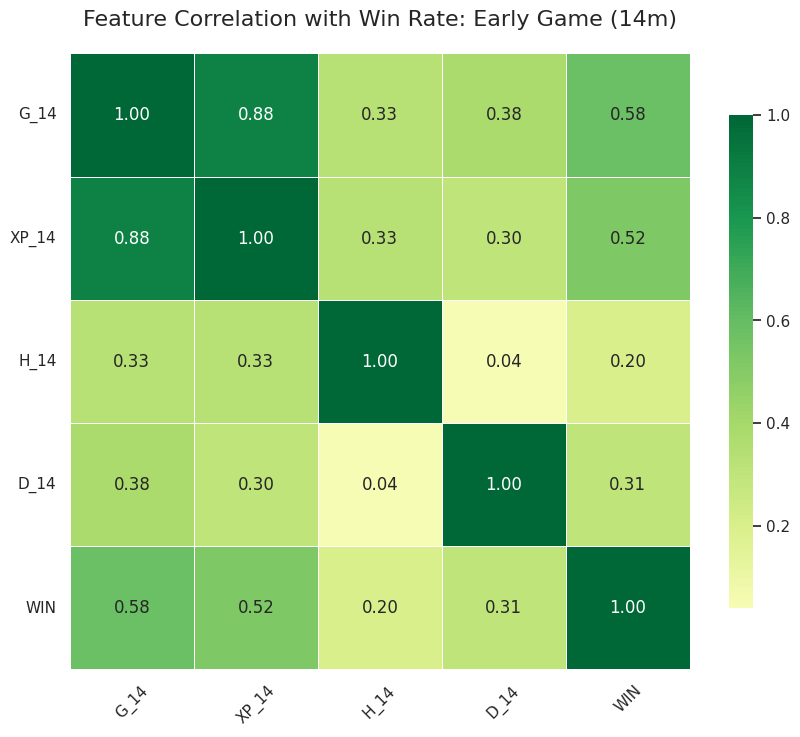

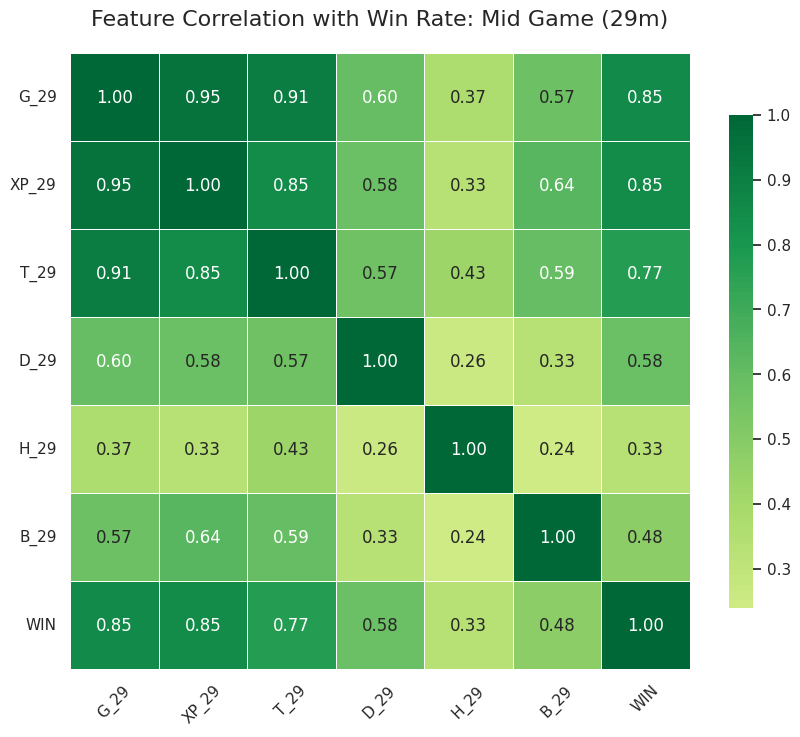

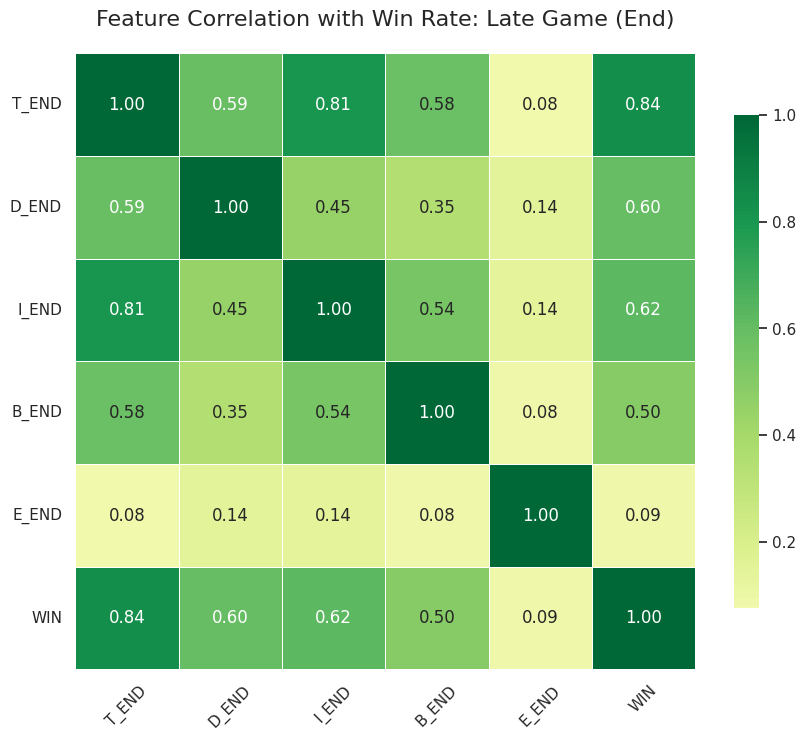

In [15]:
def plot_correlation_heatmap(file_path, phase_name):
    """
    Generates a professional correlation heatmap for game statistics.
    """
    try:
        df = pd.read_csv(file_path)
        
        # Filter only non-champion columns (Stats + WIN)
        stats_cols = [col for col in df.columns if col not in all_champ]
        corr_matrix = df[stats_cols].corr()

        # Set plot style
        sns.set_theme(style="white")
        plt.figure(figsize=(10, 8))
        
        # Create heatmap with improved aesthetics
        heatmap = sns.heatmap(
            corr_matrix, 
            annot=True, 
            cmap='RdYlGn', 
            fmt=".2f", 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8}
        )
        
        plt.title(f"Feature Correlation with Win Rate: {phase_name}", fontsize=16, pad=20)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.show()
        
    except FileNotFoundError:
        print(f"File not found: {file_path}")

# --- Execute for all phases using a loop ---
dataset_paths = {
    "Early Game (14m)": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_early.csv",
    "Mid Game (29m)": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_mid.csv",
    "Late Game (End)": "/kaggle/input/datasets/onphct/lol-matrix-information-2/matrix_late.csv"
}

for phase, path in dataset_paths.items():
    plot_correlation_heatmap(path, phase)

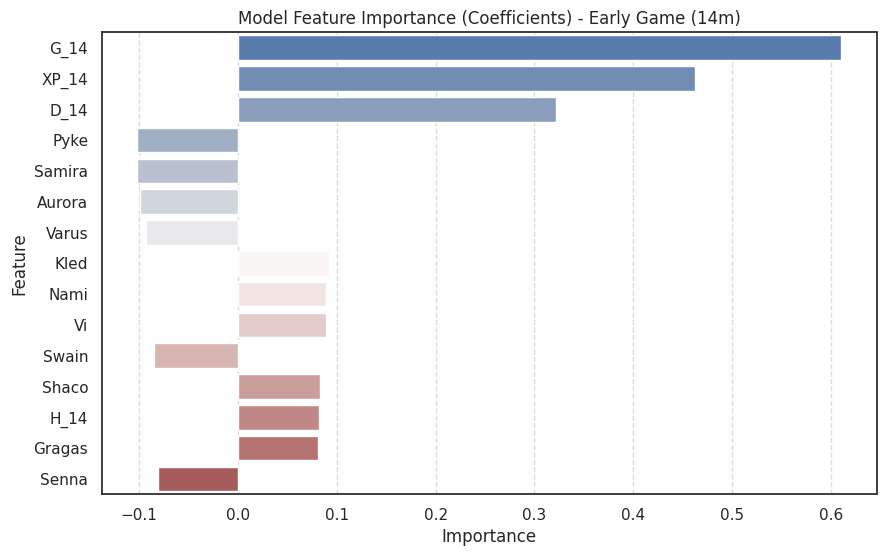

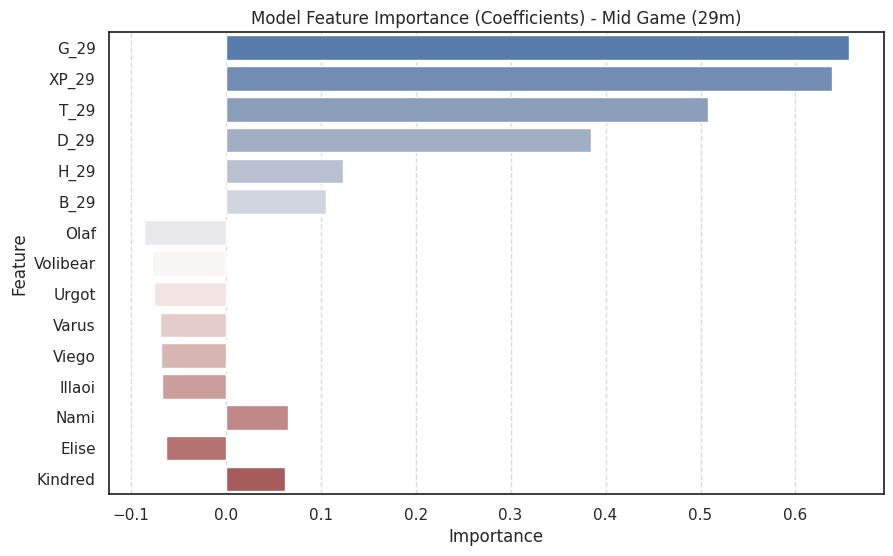

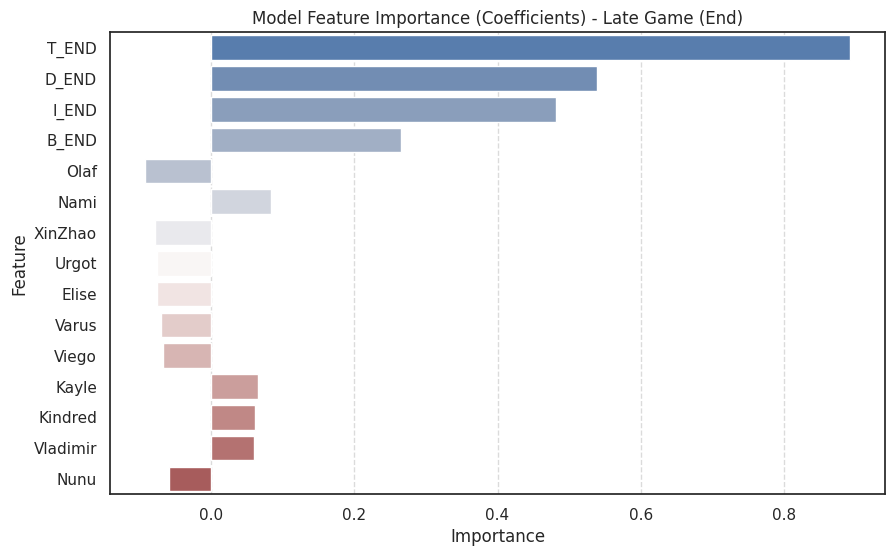

In [16]:
# Vẽ biểu đồ các hệ số quan trọng nhất của Model
def plot_feature_importance(model_file, phase_name, feature_names):
    # Lấy các hệ số (coefficients)
    model = joblib.load(model_file)
    importance = model.coef_[0]
    
    # Tạo DataFrame để dễ vẽ
    feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    # Chỉ lấy top 15 cái quan trọng nhất (cả âm và dương)
    feat_importance['abs_importance'] = feat_importance['Importance'].abs()
    top_feats = feat_importance.sort_values(by='abs_importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=top_feats, hue='Feature', palette='vlag', legend=False)
    plt.title(f"Model Feature Importance (Coefficients) - {phase_name}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

early_features = all_champ + ['G_14', 'XP_14', 'H_14', 'D_14']
plot_feature_importance("model_early_game.joblib", "Early Game (14m)", early_features)

mid_features = all_champ + ['G_29', 'XP_29', 'T_29', 'D_29', 'H_29', 'B_29']
plot_feature_importance("model_mid_game.joblib", "Mid Game (29m)", mid_features)

late_features = all_champ + ['T_END', 'D_END', 'I_END', 'B_END', 'E_END']
plot_feature_importance("model_late_game.joblib", "Late Game (End)", late_features)
